# Топологические метрики схожести облаков точек: калибровка, направленность и применение к галлюцинациям LLM

Финальный тонкий ноутбук курсовой работы. Читает готовые артефакты `results/` (таблицы CSV, сводные JSON, сырые parquet-строки единой schema), ничего тяжёлого не пересчитывает: только pandas / numpy / matplotlib. Пакет `tda_metrics` не импортируется.

## §0. Окружение и воспроизводимость

**Вопрос.** В каком окружении исполняется ноутбук, какие артефакты он читает и как воспроизвести всё с нуля?

In [ ]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA = 'results'
if not os.path.isdir(DATA):
    raise FileNotFoundError(
        f'артефакты не найдены: каталог {DATA!r} не существует; '
        'запустите ноутбук из корня репозитория, где лежит results/')

EXPECTED = [
    'tables/s0_floors.csv',
    'tables/s1_z.csv',
    'tables/s3_grid.csv',
    'tables/s3_sensitivity.csv',
    'tables/s4_first_detected.csv',
    'tables/cv_samelaw_floors.csv',
    'tables/cv_c1_contrasts.csv',
    'tables/cv_c1_sensitivity.csv',
    'tables/power_min_n.csv',
    'tables/power_summary.csv',
    'tables/power_notes.json',
    'tables/w3_c3_matched.csv',
    'tables/w3_llm_controls.csv',
    'tables/llm_extraction_manifest.csv',
    'raw/wave5/test_summary.json',
    'raw/wave5/verdict.json',
    'raw/wave5/layerwise_summary.json',
    'raw/wave5/test.parquet',
    'raw/llm/results.parquet',
    'raw/llm_cache/manifest.json',
]
present = {rel: os.path.isfile(os.path.join(DATA, rel)) for rel in EXPECTED}
for rel, ok in present.items():
    print('OK  ' if ok else 'НЕТ ', rel)
print(f'\nнайдено {sum(present.values())}/{len(EXPECTED)} ожидаемых артефактов в {DATA!r}')

OK   tables/s0_floors.csv
OK   tables/s1_z.csv
OK   tables/s3_grid.csv
OK   tables/s3_sensitivity.csv
OK   tables/s4_first_detected.csv
OK   tables/cv_samelaw_floors.csv
OK   tables/cv_c1_contrasts.csv
OK   tables/cv_c1_sensitivity.csv
OK   tables/power_min_n.csv
OK   tables/power_summary.csv
OK   tables/power_notes.json
OK   tables/w3_c3_matched.csv
OK   tables/w3_llm_controls.csv
OK   tables/llm_extraction_manifest.csv
OK   raw/wave5/test_summary.json
OK   raw/wave5/verdict.json
OK   raw/wave5/layerwise_summary.json
OK   raw/wave5/test.parquet
OK   raw/llm/results.parquet
OK   raw/llm_cache/manifest.json

найдено 20/20 ожидаемых артефактов в 'results'


**Ответ.** Все числа и фигуры ниже получены из зафиксированных артефактов экспериментальных прогонов (Colab GPU, supervisor-циклы; хроника — `docs/orchestration/`); ноутбук сам ничего не вычисляет, кроме агрегаций по готовым таблицам.

Воспроизводимость:
- версия репозитория: git-хэш `0a54641` (Wave 2/3/5); ноутбук генерируется скриптом `scripts/build_final_notebook.py` (только stdlib), перегенерация: `python3 scripts/build_final_notebook.py`;
- конвенции сидов всюду: P = «данные» (seed 42+1000·k), Q = «модель» (seed 7+1000·k); облака всегда с разными сидами; деформации — метод общих случайных чисел;
- NTD: в общей формуле `ntd(X, Y)` X — «модель» (оцениваемое облако), Y — «данные» (референс); в колонках `ntd_PQ`/`ntd_QP` первая буква — X, вторая — Y;
- сплиты LLM-части — по `prompt_id` (60/20/20, seed 0), `prompt_ids_hash` зафиксирован в каждой raw-строке;
- ноутбук не пересчитывает тяжёлое: эмбеддинги, персистентные гомологии и метрики уже вычислены в raw-артефактах.

Ограничения чтения: parquet-файлы читаются pandas'ом (нужен pyarrow); при отсутствии `results/` ноутбук останавливается с внятной ошибкой в первой же ячейке.

## §1. Постановка, обозначения и метрики

**Вопрос.** Что именно сравнивают метрики и как читать направления `PQ`/`QP` словами?

**Ответ. Постановка.** Сравниваются два облака точек: P = «данные» и Q = «модель». Все метрики — несходство: минимум при совпадении законов, рост при различии.

**Метрики.**
- **MTD** (magnitude topological difference) — асимметричная, считается в обоих направлениях; скор — сумма длин H1-баров кросс-диаграммы; сырые значения зависят от геометрии пространства.
- **NTD** (normalized topological divergence, Dmitriev et al., IEEE Access 2025) — кросс-расходимость mtd⁰, нормированная на шумовой пол референса; `ntd(X, Y)`: X — «модель», Y — «данные»; около 1 — один закон; пол кросс-пространственный O(1), поэтому raw-NTD сравнима между пространствами.
- **RTD** — симметричная, требует |P| = |Q|; на независимых облаках используется off-label random-coupling (`rtd_trials=2`) — exploratory с обязательной маркировкой; paired-режим (замены в парных точках) методологически естественнее.
- **improved precision/recall@k** — indicator-метрики: recall@k — доля точек данных с k достаточно близкими соседями из модели; precision@k — доля точек модели с k близкими соседями из данных; один вызов возвращает обе.
- **MMD, Fréchet, JS** — статистические: видят сдвиг распределений в целом, но не различают тип ошибки.

**Направления словами** (сквозная конвенция проекта):
- **recall-тип** — `mtd_PQ`, `ntd_PQ`, `recall@k`: «покрытие» — все ли структуры *данных* присутствуют в *модели*; деградирует при **mode dropping** (модель потеряла моды данных);
- **precision-тип** — `mtd_QP`, `ntd_QP`, `precision@k`: «чистота» — не содержит ли *модель* структур, которых нет в *данных*; деградирует при **mode invention** (модель добавила внешние моды).

**Контроль всюду** — same-law: P и Q — независимые выборки одного закона (разные сиды); их среднее = «шумовой пол» метрики. Raw-значения MTD/RTD/Fréchet между пространствами несравнимы (разные геометрические шкалы) — сравнение внутри пространства или через z/NTD.

## §2. Калибровка и same-law полы

**Вопрос.** Каков «шумовой пол» каждой метрики, когда P и Q — выборки одного закона? Какие полы сопоставимы между пространствами?

S0, синтетика: same-law полы (mean по 5 сидам)
                  ntd_PQ     rtd mtd_PQ
                    mean    mean   mean
distribution n                         
gaussian     250   2.213  20.456  3.341
             500   1.312  37.328  5.008
             1000  1.312  37.184  7.435
mixture      250   2.348  20.132  2.751
             500   1.333  36.139  4.460
             1000  1.205  36.455  6.547
ring         250   2.281  16.526  2.128
             500   1.356  28.535  3.270
             1000  1.254  28.357  5.004

C0, CV: same-law полы (n=1000, mean по 5 повторам)
metric                 mtd_PQ  ntd_PQ  ntd_QP     rtd  precision@3  recall@3  frechet
space                                                                                
cifar_pixels_pca16  58235.817   1.253   1.250  35.902        0.809     0.801  238.329
clip_pca16              4.383   1.255   1.223  40.394        0.895     0.890    0.013
clip_raw                3.647   1.253   1.235  36.726        0.848     0.833 

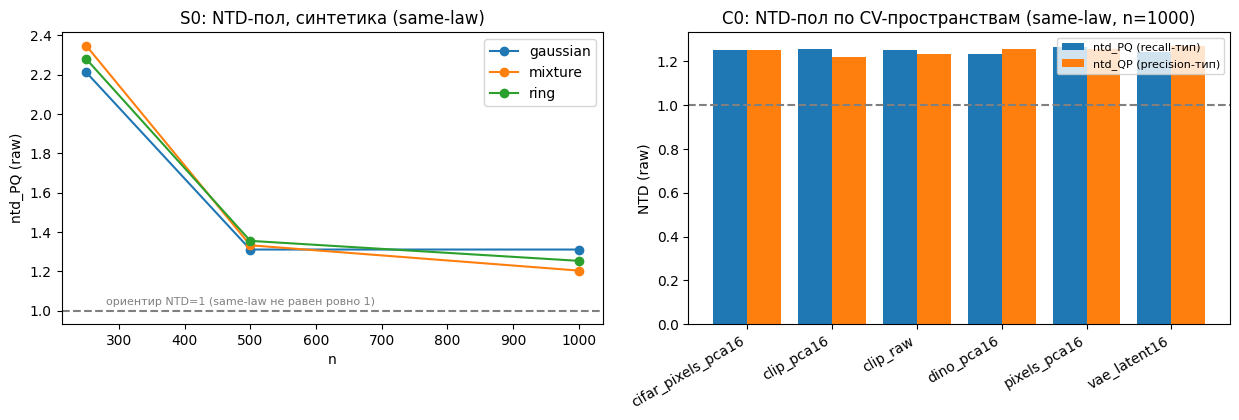

In [ ]:
path = f'{DATA}/tables/s0_floors.csv'
s0 = pd.read_csv(path, header=[0, 1], index_col=[0, 1], skiprows=[2])
s0.index = s0.index.set_names(['distribution', 'n'])
print('S0, синтетика: same-law полы (mean по 5 сидам)')
print(s0[[('ntd_PQ', 'mean'), ('rtd', 'mean'), ('mtd_PQ', 'mean')]].round(3).to_string())

cv = pd.read_csv(f'{DATA}/tables/cv_samelaw_floors.csv')
cv_tab = cv.pivot(index='space', columns='metric', values='mean')
cols = ['mtd_PQ', 'ntd_PQ', 'ntd_QP', 'rtd', 'precision@3', 'recall@3', 'frechet']
print('\nC0, CV: same-law полы (n=1000, mean по 5 повторам)')
print(cv_tab[cols].round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3))
ax = axes[0]
for dist, grp in s0.groupby(level=0, sort=True):
    ax.plot(grp.index.get_level_values('n'), grp[('ntd_PQ', 'mean')], marker='o', label=dist)
ax.axhline(1.0, linestyle='--', color='grey')
ax.annotate('ориентир NTD=1 (same-law не равен ровно 1)', (280, 1.03), fontsize=8, color='grey')
ax.set_title('S0: NTD-пол, синтетика (same-law)')
ax.set_xlabel('n')
ax.set_ylabel('ntd_PQ (raw)')
ax.legend()

ax = axes[1]
x = np.arange(len(cv_tab))
ax.bar(x - 0.2, cv_tab['ntd_PQ'], 0.4, label='ntd_PQ (recall-тип)')
ax.bar(x + 0.2, cv_tab['ntd_QP'], 0.4, label='ntd_QP (precision-тип)')
ax.set_xticks(x)
ax.set_xticklabels(cv_tab.index, rotation=30, ha='right')
ax.axhline(1.0, linestyle='--', color='grey')
ax.set_title('C0: NTD-пол по CV-пространствам (same-law, n=1000)')
ax.set_ylabel('NTD (raw)')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

**Ответ.**
- Синтетика (S0): полы растут с n (RTD: 16.5-37.3; MTD: 2.1-7.4 при n 250-1000); NTD-пол при n>=500 выходит на полосу **1.20-1.36** (при n=250 около 2.2 — подвыборки знаменателя пересекаются, гранулярность). Точная копия даёт идеальные значения: mmd = 0, precision@3 = 1.
- CV (C0, 6 пространств): NTD-пол **1.22-1.27 во всех пространствах** — кросс-пространственная O(1)-полоса, согласуется с синтетикой при n>=500; mmd и js на полу ровно 0.
- RTD-пол высокий (36-50 raw в CV; растёт с n в синтетике) и геометрически/n-зависим — raw-RTD сравнима только внутри серии при равном n.

Ограничения (рядом с результатом): raw-значения MTD (4.4-58236) и Fréchet (0.013-238) несравнимы между пространствами — в таблице они приведены только как справочные полы своих пространств; «полоса NTD около 1.2» валидна при n>=500 (артефакт n=250 завышен); P/Q в CV — конечные подвыборки одного датасета (ожидаемое пересечение около 1.5-3% облака), а не идеализированные независимые выборки закона (MUST-оговорка F-1, отчёт wave2-3-5 §14).

## §3. Направленные ошибки: dropping × invention

**Вопрос.** Какие преобразования видит каждая метрика (карта инвариантов S1) и селективны ли направленные метрики к двум независимым типам ошибки на сетке dropping × invention (S3)?

S1: знаковые z на максимальном уровне (хуже = +; z=0 — same-law)
transformation  shift  rotation  scale  anisotropy  thickness  reflection
metric                                                                   
frechet         137.8      -0.2   32.2       149.3        0.6        -0.4
js               41.0       0.3   31.4        35.8        4.6         0.2
mmd              46.5       0.0   16.6        37.8        0.5         0.0
mtd_PQ           13.1      -0.5   22.3        25.3        5.6         0.5
mtd_QP           12.7       0.4   25.5        32.6        9.3         0.4
ntd_PQ           52.8      -0.9    5.7        -2.1       -8.1        -1.1
ntd_QP           11.7      -0.1   15.3        33.4        4.4        -0.1
precision@10    849.8      -1.2  407.6       925.6       42.8        -0.2
precision@3     207.0      -0.6  138.0       218.9       20.4         0.2
recall@10       388.6      -0.0    8.3        88.8       -1.1         0.1
recall@3        208.2       1.2   23.7        8

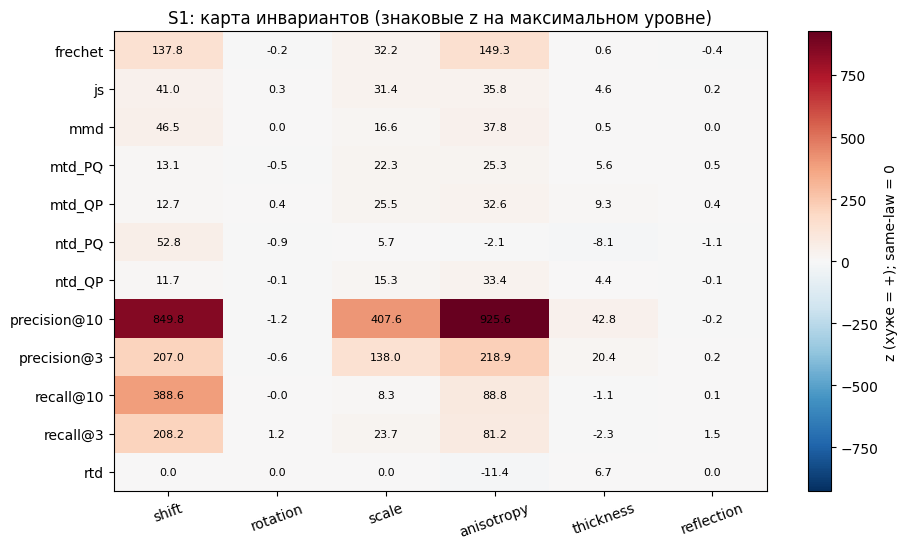

In [ ]:
path = f'{DATA}/tables/s1_z.csv'
z = pd.read_csv(path)
is_max = z['level'] == z.groupby('transformation')['level'].transform('max')
trafos = ['shift', 'rotation', 'scale', 'anisotropy', 'thickness', 'reflection']
zm = z[is_max].pivot(index='metric', columns='transformation', values='z_signed')[trafos]
print('S1: знаковые z на максимальном уровне (хуже = +; z=0 — same-law)')
print(zm.round(1).to_string())

fig, ax = plt.subplots(figsize=(9.5, 5.6))
vmax = float(np.abs(zm.values).max())
im = ax.imshow(zm.values, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_xticks(range(len(trafos)), trafos, rotation=20)
ax.set_yticks(range(len(zm.index)), zm.index)
for i in range(zm.shape[0]):
    for j in range(zm.shape[1]):
        ax.text(j, i, f'{zm.values[i, j]:.1f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax, label='z (хуже = +); same-law = 0')
ax.set_title('S1: карта инвариантов (знаковые z на максимальном уровне)')
fig.tight_layout()
plt.show()

S3: чувствительность по осям на максимальном уровне (signed: хуже = +; twosided: max|Δ|)
      metric     kind  drop_sensitivity  invent_sensitivity
      mtd_PQ   signed              5.05                7.81
      mtd_QP   signed              2.68               -0.91
      ntd_PQ twosided              4.44                0.10
      ntd_QP twosided              0.21                1.74
         rtd twosided              4.27                2.46
 precision@3   signed              0.01                0.40
    recall@3   signed              0.73               -0.00
precision@10   signed              0.00                0.41
   recall@10   signed              0.74                0.00
         mmd   signed              0.66                0.18
     frechet   signed              9.07                2.87
          js   signed              0.52                0.24


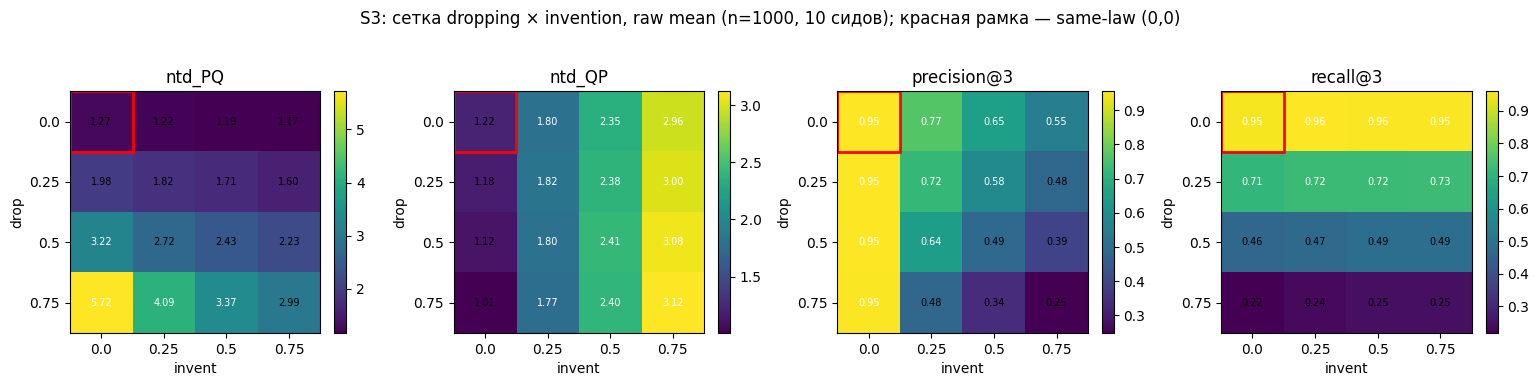

In [ ]:
path = f'{DATA}/tables/s3_grid.csv'
s3 = pd.read_csv(path, header=[0, 1], index_col=[0, 1], skiprows=[2])
s3.index = s3.index.set_names(['drop', 'invent'])
sens = pd.read_csv(f'{DATA}/tables/s3_sensitivity.csv')
print('S3: чувствительность по осям на максимальном уровне (signed: хуже = +; twosided: max|Δ|)')
print(sens.round(2).to_string(index=False))

d_vals = sorted(s3.index.get_level_values('drop').unique())
i_vals = sorted(s3.index.get_level_values('invent').unique())
panel_metrics = ['ntd_PQ', 'ntd_QP', 'precision@3', 'recall@3']
fig, axes = plt.subplots(1, 4, figsize=(15.5, 3.7))
for ax, metric in zip(axes, panel_metrics):
    grid = s3[(metric, 'mean')].unstack('invent').loc[d_vals, i_vals]
    im = ax.imshow(grid.values, cmap='viridis', aspect='auto')
    vmax = float(np.nanmax(grid.values))
    for a in range(len(d_vals)):
        for b in range(len(i_vals)):
            value = grid.values[a, b]
            ax.text(b, a, f'{value:.2f}', ha='center', va='center', fontsize=7,
                    color='white' if value > 0.55 * vmax else 'black')
    ax.set_xticks(range(len(i_vals)), [str(v) for v in i_vals])
    ax.set_yticks(range(len(d_vals)), [str(v) for v in d_vals])
    ax.set_xlabel('invent')
    ax.set_ylabel('drop')
    ax.set_title(metric)
    ax.add_patch(plt.Rectangle((-0.5, -0.5), 1, 1, fill=False, edgecolor='red', lw=2))
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle('S3: сетка dropping × invention, raw mean (n=1000, 10 сидов); красная рамка — same-law (0,0)', y=1.03)
fig.tight_layout()
plt.show()

**Ответ.**
- **S1, инварианты**: RTD — чистый детектор формы: z = 0 на shift/rotation/scale (положительный контроль инвариантности работает) и большие |z| на anisotropy/thickness. Кросс-метрики (MMD/Fréchet/PR) — детекторы положения/масштаба: огромные z на shift/scale/anisotropy и около 0 на rotation/reflection (изометрии). ntd_PQ на сдвиге z = +52.8: сдвиг = непокрытие.
- **S3, зеркальная сигнатура** (heatmap): recall-тип ловит только drop-ось (ntd_PQ +4.44 против +0.10; recall@3 +0.73 против −0.00), precision-тип — только invent-ось (ntd_QP +0.21/+1.74; precision@3 +0.005/+0.40). Статистические (mmd 0.66/0.18) и mtd_PQ (+5.05/+7.81) видят обе оси и не различают тип ошибки.

Ограничения: drop-ось сдвигает среднее Q (удаляются моды), invent при фиксированном |Q| разреживает покрытие — отклик кросс-метрик (MTD/MMD/Fréchet) смешивает непокрытие со сдвигом/ковариацией (ограничение дизайна сетки, не баг); mtd_PQ реагирует и на invent — реальный recall-эффект разреживания, селективность держат NTD и PR; z — эффект-сайзы (σ0 по same-law сидам), не p-значения; для mmd z неинтерпретируем (σ0 около 0 из-за клипа отрицательных MMD²). Полные формулировки — синтетический REPORT §14.

## §4. Раннее обнаружение

**Вопрос.** На каком минимальном уровне деформации каждая метрика впервые обнаруживает изменение, и совпадает ли направление детекции с типом ошибки?

S4: первое обнаружение (Welch 95% CI весь «хуже нуля», 10 сидов)
  axis       metric  first_detected  direction_share  actual_changes
  drop       mtd_PQ            0.10              0.8             1.0
  drop       mtd_QP            0.20              1.0             2.0
  drop       ntd_PQ            0.10              1.0             1.0
  drop       ntd_QP               —                —               —
  drop          rtd               —                —               —
  drop  precision@3               —                —               —
  drop     recall@3            0.10              1.0             1.0
  drop precision@10               —                —               —
  drop    recall@10            0.10              1.0             1.0
  drop          mmd            0.10              1.0             1.0
  drop      frechet            0.10              1.0             1.0
  drop           js            0.10              1.0             1.0
invent       mtd_PQ            0.15   

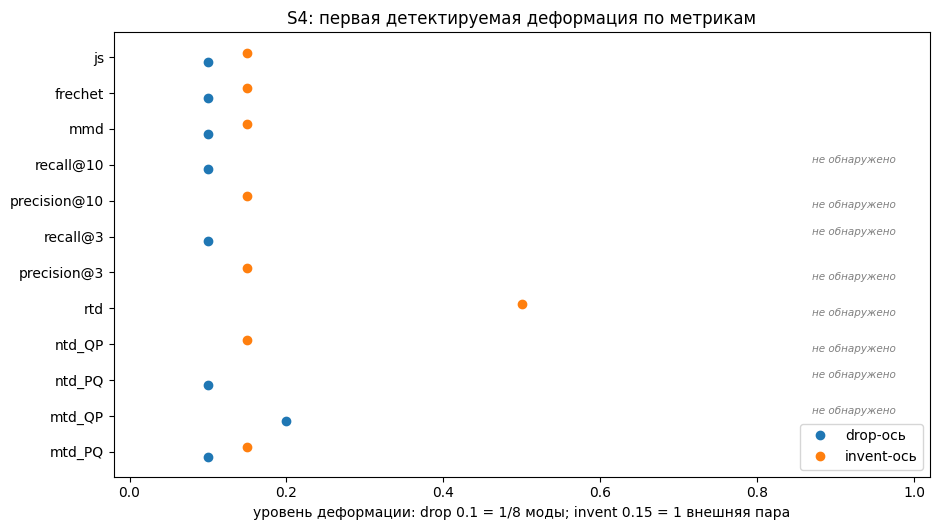

In [ ]:
path = f'{DATA}/tables/s4_first_detected.csv'
fd = pd.read_csv(path)
print('S4: первое обнаружение (Welch 95% CI весь «хуже нуля», 10 сидов)')
print(fd[['axis', 'metric', 'first_detected', 'direction_share', 'actual_changes']]
      .to_string(index=False, na_rep='—'))

metrics = fd[fd['axis'] == 'drop']['metric'].tolist()
axis_color = {'drop': 'tab:blue', 'invent': 'tab:orange'}
fig, ax = plt.subplots(figsize=(9.5, 5.4))
ax.plot([], [], 'o', color=axis_color['drop'], label='drop-ось')
ax.plot([], [], 'o', color=axis_color['invent'], label='invent-ось')
for k, metric in enumerate(metrics):
    for axis, dy in [('drop', 0.0), ('invent', 0.26)]:
        row = fd[(fd['axis'] == axis) & (fd['metric'] == metric)]
        first = row['first_detected'].iloc[0]
        if pd.notna(first):
            ax.plot(first, k + dy, 'o', color=axis_color[axis])
        else:
            ax.text(0.87, k + dy, 'не обнаружено', fontsize=7.5, va='center',
                    color='grey', style='italic')
ax.set_yticks([k + 0.13 for k in range(len(metrics))], metrics)
ax.set_xlabel('уровень деформации: drop 0.1 = 1/8 моды; invent 0.15 = 1 внешняя пара')
ax.set_xlim(-0.02, 1.02)
ax.legend(loc='lower right')
ax.set_title('S4: первая детектируемая деформация по метрикам')
fig.tight_layout()
plt.show()

**Ответ.** Все обнаружения — на первом ненулевом уровне дискретной сетки: **drop 0.1 = 1/8 моды** и **invent 0.15 = 1 внешняя пара**; направление всюду правильное (direction_share = 1.0, кроме mtd_PQ на drop: 0.8):
- drop-ось ловят: mtd_PQ, ntd_PQ, recall@3/@10, mmd, frechet, js (уровень 0.1), mtd_QP (0.2); **слепы: ntd_QP, precision@3/@10** (не обнаруживают до 0.75);
- invent-ось ловят: mtd_PQ, ntd_QP, precision@3/@10, mmd, frechet, js (0.15), rtd (0.5); **слепы: mtd_QP, ntd_PQ, recall@3/@10**.

Зеркальная селективность воспроизводится и в раннем обнаружении: indicator-метрики ловят минимальную деформацию сетки только в «своём» направлении.

Ограничения: критерий S4 (Welch 95% CI без BH-поправки) — exploratory; уровни дискретны (тоньше сетки проверить нельзя), уровни 0.05/0.1 на invent-оси — no-op (заменять нечего); эффект-сайзы достигают десятков из-за малых σ0 same-law (MUST-оговорка №3 синтетического REPORT §14).

## §5. CV: классы, представления и цикл

**Вопрос.** Переносится ли направленная сигнатура S3 на реальные данные, где «мода» = класс MNIST (рабочая гипотеза, не постулат)? Каковы первые обнаруживаемые уровни по порогу |z|>=3 в 5 CV-пространствах (CLIP raw, CLIP PCA-16, DINO PCA-16, VAE-латент, пиксели PCA-16)?


c1_drop: уровень первого |z|>=3 (пусто = не достигается)
space        clip_pca16  clip_raw  dino_pca16  pixels_pca16  vae_latent16
metric                                                                   
ntd_PQ              0.4       0.4         0.4           0.3           0.3
ntd_QP                —         —           —             —             —
precision@3           —         —           —             —             —
recall@3            0.1       0.2         0.2           0.2           0.1

c1_invent: уровень первого |z|>=3 (пусто = не достигается)
space        clip_pca16  clip_raw  dino_pca16  pixels_pca16  vae_latent16
metric                                                                   
ntd_PQ                —         —           —             —             —
ntd_QP              0.1       0.2         0.3           0.2           0.2
precision@3         0.1       0.1         0.2           0.1           0.1
recall@3              —         —           —             —         

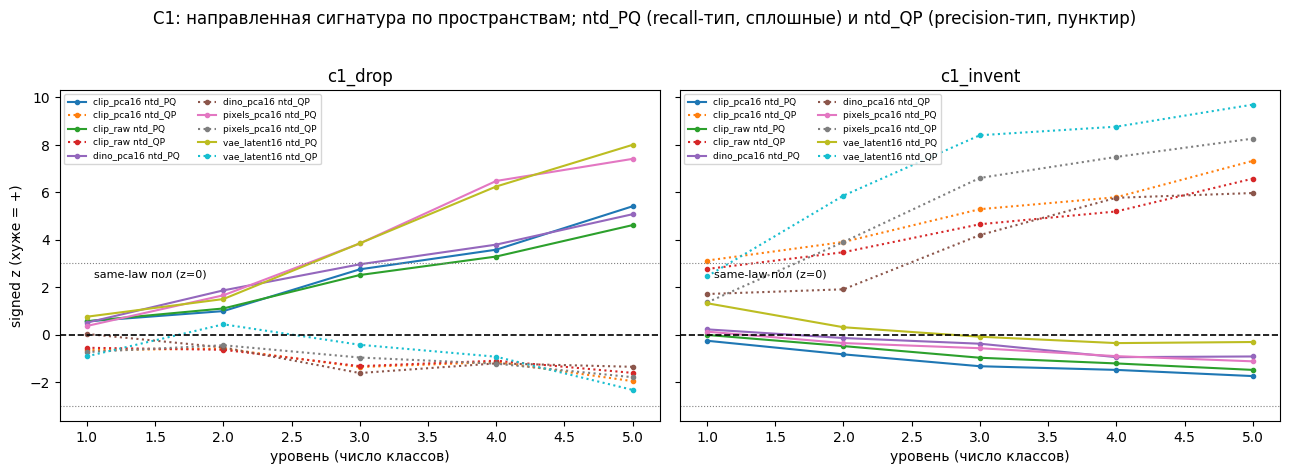


Пример raw-значений (clip_pca16; mean по 5 повторам, пол = floor_mean):
   family metric  level_classes  mean  floor_mean  signed_z_worse
  c1_drop ntd_PQ              1 1.281       1.255           0.556
  c1_drop ntd_PQ              2 1.300       1.255           0.989
  c1_drop ntd_PQ              3 1.380       1.255           2.751
  c1_drop ntd_PQ              4 1.418       1.255           3.580
  c1_drop ntd_PQ              5 1.501       1.255           5.411
  c1_drop ntd_QP              1 1.198       1.223          -0.660
  c1_drop ntd_QP              2 1.200       1.223          -0.591
  c1_drop ntd_QP              3 1.171       1.223          -1.370
  c1_drop ntd_QP              4 1.179       1.223          -1.158
  c1_drop ntd_QP              5 1.149       1.223          -1.966
c1_invent ntd_PQ              1 1.244       1.255          -0.262
c1_invent ntd_PQ              2 1.217       1.255          -0.835
c1_invent ntd_PQ              3 1.195       1.255          -1.336
c1_

In [ ]:
path = f'{DATA}/tables/cv_c1_contrasts.csv'
cc = pd.read_csv(path)
sens = pd.read_csv(f'{DATA}/tables/cv_c1_sensitivity.csv')

key_metrics = ['ntd_PQ', 'ntd_QP', 'precision@3', 'recall@3']
spaces = sorted(cc['space'].unique())
for family in ['c1_drop', 'c1_invent']:
    sub = sens[(sens['family'] == family) & (sens['metric'].isin(key_metrics))]
    tab = sub.pivot(index='metric', columns='space', values='first_level_z3')
    print(f'\n{family}: уровень первого |z|>=3 (пусто = не достигается)')
    print(tab[spaces].to_string(na_rep='—'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
for ax, family in zip(axes, ['c1_drop', 'c1_invent']):
    for space in spaces:
        sub = cc[(cc['family'] == family) & (cc['space'] == space)]
        for metric, ls in [('ntd_PQ', '-'), ('ntd_QP', ':')]:
            curve = sub[sub['metric'] == metric].sort_values('level_classes')
            ax.plot(curve['level_classes'], curve['signed_z_worse'], ls, marker='o', ms=3,
                    label=f'{space} {metric}')
    ax.axhline(0.0, color='black', linestyle='--', lw=1.2)
    ax.annotate('same-law пол (z=0)', (1.05, 2.4), fontsize=8)
    ax.axhline(3.0, color='grey', linestyle=':', lw=0.8)
    ax.axhline(-3.0, color='grey', linestyle=':', lw=0.8)
    ax.set_xlabel('уровень (число классов)')
    ax.set_title(family)
    ax.legend(fontsize=6.5, ncol=2)
axes[0].set_ylabel('signed z (хуже = +)')
fig.suptitle('C1: направленная сигнатура по пространствам; ntd_PQ (recall-тип, сплошные) и ntd_QP (precision-тип, пунктир)', y=1.02)
fig.tight_layout()
plt.show()

sub = cc[(cc['space'] == 'clip_pca16') & (cc['metric'].isin(['ntd_PQ', 'ntd_QP']))]
print('\nПример raw-значений (clip_pca16; mean по 5 повторам, пол = floor_mean):')
print(sub[['family', 'metric', 'level_classes', 'mean', 'floor_mean', 'signed_z_worse']]
      .round(3).to_string(index=False))

**Контекст фазы 1** (executed-артефакт `results/topology_metrics_output.ipynb`): зависимость сигнатуры от представления была известна до новой фазы — цитаты текстом:

> «CLIP/DINO инвариантны к повороту MNIST-цифр — цикл вращения невидим топологическим метрикам через эти эмбеддеры (контроль «круг vs круг» = «круг vs дуга»); в VAE-латенте RTD видит (41 vs 28); на CIFAR-поворотах CLIP реагирует остро — слепота домен-специфична, свойство эмбеддера, не метрики».

> «На 512-мерных CLIP-эмбеддингах improved PR почти слеп (precision@10 около 0.003) — PCA-16 ремонтирует (0.34; на CIFAR-деградации до 1.00), внутренний оптимум d около 16».

Именно из-за этой зависимости выбор пространств новой фазы зафиксирован как clip_raw / clip_pca16 / dino_pca16 / vae_latent16 / pixels_pca16 (+ cifar_pixels_pca16 для C0); C2-ротация в новой фазе не исполнялась (сжатые сроки, задокументировано в PROJECT_STATE).

**Ответ.** Зеркальная сигнатура S3 **воспроизводится на реальных классах во всех 5 C1-пространствах** (грид 250 конфигов, 5 повторов, n=1000, |P|=|Q|, класс-сбалансированные квоты):
- drop-ось: recall-семейство детектирует (recall@10 z до +78.9 в VAE; в clip_pca16 recall@1 +26.8), ntd_PQ растёт (до +5.4), ntd_QP уходит вниз (−2.0); precision@k слепы (|z| <= 2.7);
- invent-ось: precision-семейство детектирует (precision@3 z до +41.5 в dino), ntd_QP растёт (+7.3…+9.7), ntd_PQ уходит вниз (−1.8); recall@k слепы (|z| <= 2.5);
- «класс = топологическая мода» — подтверждённая рабочая гипотеза (проверяемая самим экспериментом, не предпосылка).

Ограничения: 6-е пространство (cifar_pixels_pca16) имеет C0-пол, но в C1-грид не входит (CIFAR фигурирует в matched-порчах, §6); drop_fraction (база P = 10 классов) и invent_fraction (знаменатель /10 при базе P = 5 классов) — несопоставимые по смыслу доли, ось X подписана числом классов (MUST-оговорка F-3); PCA fit на полном пуле до выбора P/Q — структурно без утечки, но P/Q — подвыборки конечного датасета (F-1); первые уровни |z|>=3: recall- и precision-метрики 0.1-0.2, ntd_PQ 0.3-0.5, ntd_QP 0.1-0.3 — см. таблицу выше.

## §6. CV: matched-shift порчи

**Вопрос.** Различают ли топологические метрики ХАРАКТЕР порчи CIFAR при (частично) выровненном общем сдвиге (matched-MMD)?

C3: matched-MMD порчи CIFAR (cifar_clip_pca16, n=1000, mean по 5 повторам)
metric            mmd  ntd_PQ  ntd_QP  precision@3  recall@3     rtd
corruption                                                          
clean           0.000   1.078   1.078        1.000     1.000   0.000
brightness      0.132   1.289   1.185        0.974     0.933  19.317
contrast        0.156   1.353   1.192        0.969     0.880  20.469
gaussian_blur   0.252   1.473   1.229        0.935     0.644  20.301
gaussian_noise  0.294   1.559   1.295        0.730     0.468  18.426


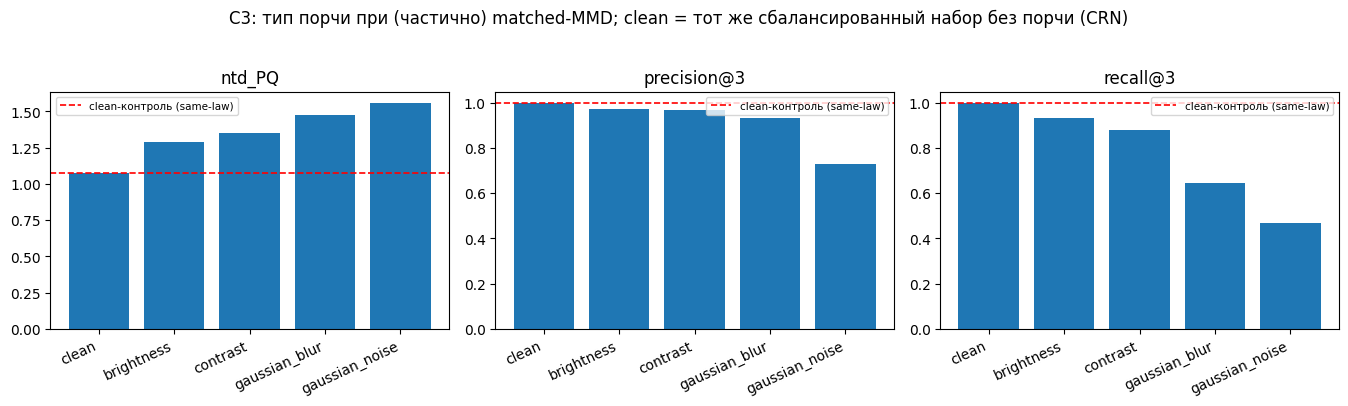

In [ ]:
path = f'{DATA}/tables/w3_c3_matched.csv'
c3 = pd.read_csv(path)
tab = c3.pivot(index='corruption', columns='metric', values='mean')
cols = ['mmd', 'ntd_PQ', 'ntd_QP', 'precision@3', 'recall@3', 'rtd']
order = ['clean', 'brightness', 'contrast', 'gaussian_blur', 'gaussian_noise']
print('C3: matched-MMD порчи CIFAR (cifar_clip_pca16, n=1000, mean по 5 повторам)')
print(tab.loc[order, cols].round(3).to_string())

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.9))
for ax, metric in zip(axes, ['ntd_PQ', 'precision@3', 'recall@3']):
    vals = tab.loc[order, metric]
    ax.bar(range(len(order)), vals.values)
    ax.set_xticks(range(len(order)), order, rotation=25, ha='right')
    ax.axhline(tab.loc['clean', metric], color='red', linestyle='--', lw=1.2,
               label='clean-контроль (same-law)')
    ax.set_title(metric)
    ax.legend(fontsize=7.5)
fig.suptitle('C3: тип порчи при (частично) matched-MMD; clean = тот же сбалансированный набор без порчи (CRN)', y=1.03)
fig.tight_layout()
plt.show()

**Ответ.** При (частично) выровненном MMD порчи различаются топологически, и **тип порчи виден в профиле метрик**:
- gaussian_noise бьёт сильнее всех по обеим осям PR (recall@3 0.468, precision@3 0.730) и по ntd_PQ (1.559);
- gaussian_blur асимметричен: recall@3 0.644 при precision@3 0.935 — потеря покрытия без внешних мод;
- brightness/contrast слабы (recall@3 >= 0.88), ntd_PQ 1.29-1.35;
- clean-контроль идеален: ntd 1.078, precision@3 = recall@3 = 1.000, rtd около 0.

Ограничения: matched-MMD выравнивание **частичное** — пересечение диапазонов MMD вырождено (brightness/contrast <= 0.15, blur/noise >= 0.25), конфаунд величины сдвига остался; тем не менее асимметрия blur (recall много меньше precision) к MMD не сводится и указывает именно на тип порчи; rtd здесь exploratory random-coupling; CRN-дизайн: P и Q из одного balanced-набора индексов, Q = corrupt(P), n=1000.

## §7. LLM pipeline и контроли

**Вопрос.** Как устроена экстракция скрытых состояний (L1) и выживает ли сигнал correct vs hallucinated после length-matched и shuffled-label контролей (L3)?

In [ ]:
path = f'{DATA}/tables/llm_extraction_manifest.csv'
man = pd.read_csv(path)
print('L1, параметры экстракции (llm_extraction_manifest.csv):')
print(man[man['field'] != 'lens'].to_string(index=False))

path = f'{DATA}/raw/llm_cache/manifest.json'
cache = json.load(open(path, encoding='utf-8'))
print('\nКэш экстракции (raw/llm_cache/manifest.json), ключевые поля:')
for key in ['model', 'n_items', 'n_records', 'answer_kinds', 'input_format',
            'pooling', 'layer_indices', 'max_length', 'truncation_share']:
    print(f'  {key}: {cache[key]}')
ans_len = cache['lens']['answer']
prompt_len = cache['lens']['prompt']
print('  длина ответа (токены): mean={mean}, p50={p50}, p90={p90}, max={max}'.format(**ans_len))
print('  длина промпта (токены): mean={mean}, p90={p90}, max={max}'.format(**prompt_len))

L1, параметры экстракции (llm_extraction_manifest.csv):
           field                                                                                                                                                                              value
    answer_kinds                                                                                                                                          {"correct": 10000, "hallucinated": 10000}
  dataset_sha256                                                                                                                   89ed139ec5e3a3169a0b30e45569ac1283846f76f27f7bb5e908ee6deed57e88
           dtype                                                                                                                                                                            float16
    input_format                                                                                                                                                

L3-пилот (dev, n=500, 5 повторов; l3e/9 отсутствует — убитый цикл):
metric                    ntd_PQ  ntd_QP  precision@3  recall@3  frechet
family             layer                                                
l3_direct          9       2.345   1.336        0.935     0.599   12.529
                   18      2.105   1.479        0.804     0.580   14.363
                   27      2.044   1.493        0.791     0.567   24.306
                   36      1.711   1.716        0.882     0.828   69.788
l3d_length_matched 9       1.840   1.389        0.860     0.774    5.735
                   18      1.793   1.472        0.714     0.686    8.436
                   27      1.802   1.488        0.582     0.532   14.304
                   36      1.522   1.669        0.708     0.684   36.879
l3e_shuffled_label 18      1.411   1.386        0.899     0.898    1.850
                   27      1.382   1.410        0.893     0.896    2.515
                   36      1.391   1.388        0.901   

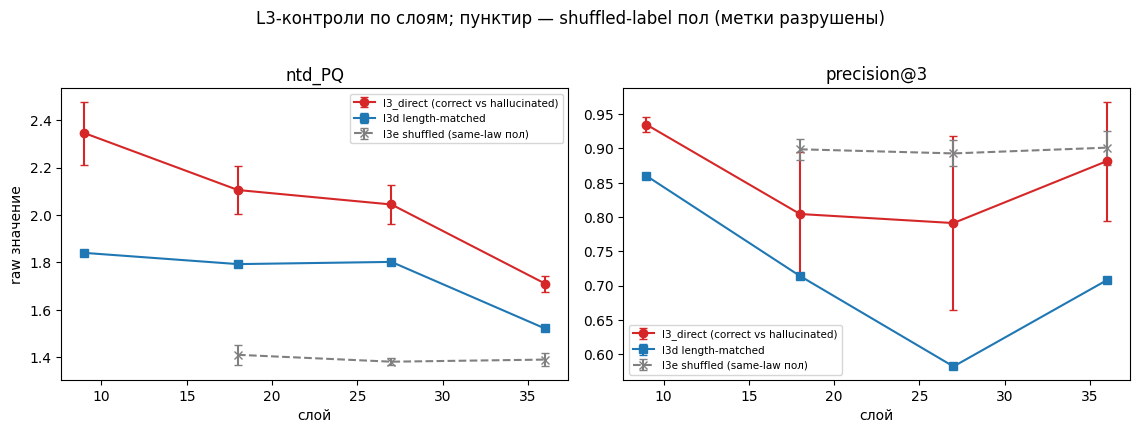

In [ ]:
path = f'{DATA}/tables/w3_llm_controls.csv'
lc = pd.read_csv(path)
key = ['ntd_PQ', 'ntd_QP', 'precision@3', 'recall@3', 'frechet']
tab = lc.pivot(index=['family', 'layer'], columns='metric', values='mean')
print('L3-пилот (dev, n=500, 5 повторов; l3e/9 отсутствует — убитый цикл):')
print(tab[key].round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
styles = [('l3_direct', 'o', 'tab:red', '-', 'l3_direct (correct vs hallucinated)'),
          ('l3d_length_matched', 's', 'tab:blue', '-', 'l3d length-matched'),
          ('l3e_shuffled_label', 'x', 'grey', '--', 'l3e shuffled (same-law пол)')]
for ax, metric in zip(axes, ['ntd_PQ', 'precision@3']):
    for family, marker, color, ls, label in styles:
        sub = lc[(lc['family'] == family) & (lc['metric'] == metric)].sort_values('layer')
        ax.errorbar(sub['layer'], sub['mean'], yerr=sub['sd'], marker=marker, color=color,
                    linestyle=ls, capsize=3, label=label)
    ax.set_xlabel('слой')
    ax.set_title(metric)
    ax.legend(fontsize=7.5)
axes[0].set_ylabel('raw значение')
fig.suptitle('L3-контроли по слоям; пунктир — shuffled-label пол (метки разрушены)', y=1.02)
fig.tight_layout()
plt.show()

**Ответ.**
- **Экстракция (L1)**: Qwen2.5-3B-Instruct (fp16), HaluEval QA 10000 пар -> **20000 пунктов** (correct 10000 + hallucinated 10000, dataset_sha256 89ed139e…); вход `chat_knowledge_v1` (knowledge в промпте, chat-шаблон); pooling `mean_answer` по answer_span; слои {9, 18, 27, 36} = 25/50/75/100% глубины; max_length 1024; **truncation_share = 0.0** по факту прогона; ответы короткие (mean 11.96, p90 24 токена), основная длина — промпт (mean 141.3).
- **Контроли (L3)**: сигнал **выживает после length-matched контроля** — l3d сохраняет отклонение от shuffled-пола на всех слоях (ntd_PQ 1.52-1.80 при поле l3e 1.38-1.41; precision@3 0.58-0.86 при поле около 0.9): различие correct/hallucinated не сводится к длине ответа (главный конфаунд). **Метка решает**: разрушение меток (l3e) возвращает всё на same-law пол — эффект именно в paired-различии ответов, не в маргинальных распределениях. l3e-пол ntd 1.38-1.41 при n=500 согласуется со скейлингом пола (1.22-1.27 при n=1000).

Ограничения: **слой-9 l3e-контроль отсутствует** (5 failed убитого цикла до фикса) — выводы по слою 9 не опираются на shuffled-контроль (MUST-оговорка §14-17 отчёта wave2-3-5); l3d снимает конфаунд длины, но не стиля ответа; хвост шаблона (`<|im_end|>` + перевод строки) входит в answer_span — константный в абсолютных токенах, но с разной относительной примесью для коротких correct и длинных hallucinated (оговорка §14-5); `chat_knowledge_v1` тестирует расхождение ответа с предоставленным knowledge-контекстом, не внутреннюю уверенность модели без опоры (оговорка §14-8).

## §8. Доля галлюцинаций

**Вопрос.** Как метрики отвечают на возрастающую долю галлюцинаций в смеси (l4a/l4b, held-out test по пре-регистрации D-010)? Подтверждается ли пре-регистрация, и каковы финальные headline-числа с bootstrap-CI?

test: слой 18, mean_answer, PCA-16, n=1000, split=test, строк ok/failed: 55/0
пороги обнаружения (same-law синтетического референса, n=1000):
  ntd_PQ: 1.445 (greater)
  ntd_QP: 1.436 (greater)
  precision@3: 0.957 (lower)
  recall@3: 0.961 (lower)

сани-чек: alpha=1.0 (l4a) тождественна l3_direct по построению
  ntd_PQ: l4a@1.0 1.8812 vs l3_direct 1.8812 — совпадают
  ntd_QP: l4a@1.0 1.3265 vs l3_direct 1.3265 — совпадают
  precision@3: l4a@1.0 0.7584 vs l3_direct 0.7584 — совпадают
  recall@3: l4a@1.0 0.6742 vs l3_direct 0.6742 — совпадают


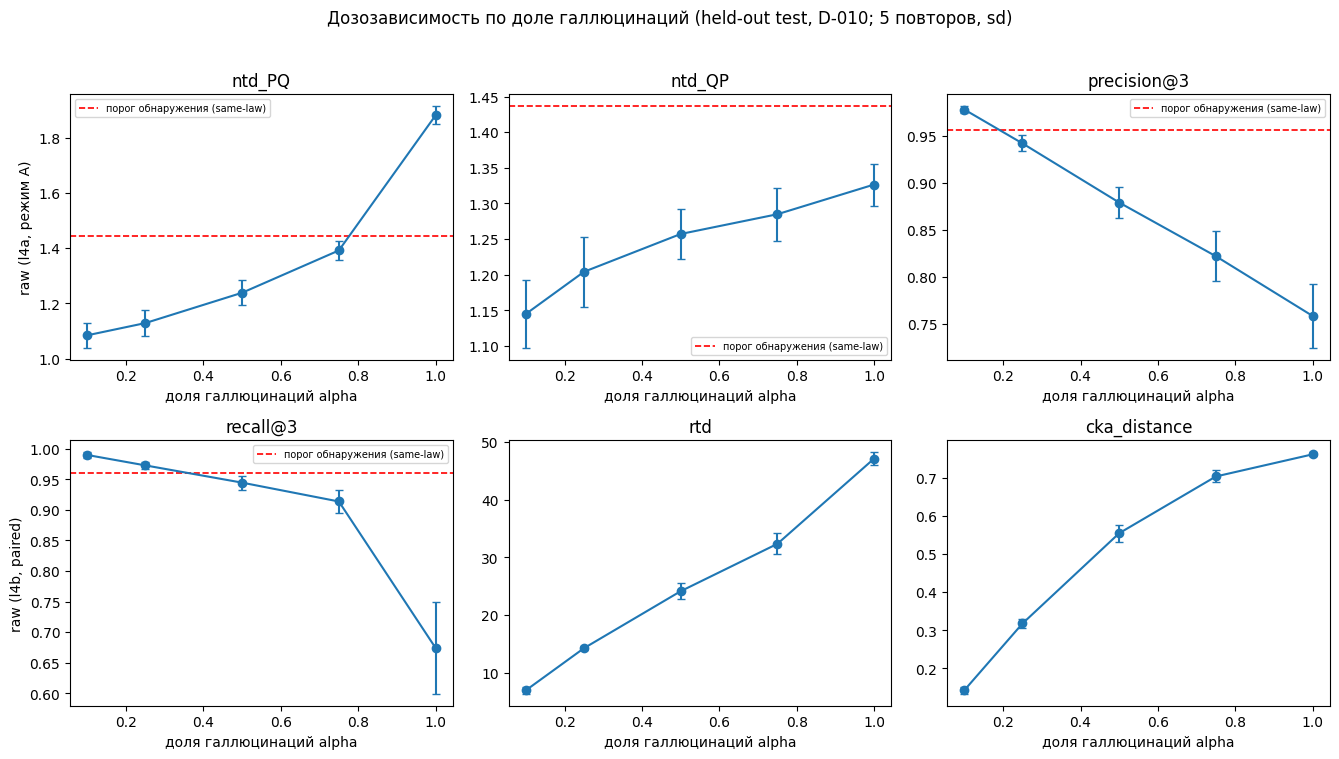

In [ ]:
path = f'{DATA}/raw/wave5/test_summary.json'
ts = json.load(open(path, encoding='utf-8'))
alphas = ts['primary_config']['alphas']
l4a = ts['primary_metrics']['l4a_independent']
l4b = ts['l4b_paired']
keymap_a = {float(k): k for k in l4a}
keymap_b = {float(k): k for k in l4b['rtd']}

series = {}
for metric in ['ntd_PQ', 'ntd_QP', 'precision@3', 'recall@3']:
    series[metric] = ([l4a[keymap_a[a]][metric]['mean'] for a in alphas],
                       [l4a[keymap_a[a]][metric]['sd'] for a in alphas])
for metric in ['rtd', 'cka_distance']:
    series[metric] = ([l4b[metric][keymap_b[a]]['mean'] for a in alphas],
                       [l4b[metric][keymap_b[a]]['sd'] for a in alphas])

path = f'{DATA}/raw/wave5/verdict.json'
vd = json.load(open(path, encoding='utf-8'))
thr = {m: vd['metrics'][m]['threshold'] for m in ['ntd_PQ', 'ntd_QP', 'precision@3', 'recall@3']}

cfg = ts['primary_config']
print(f"test: слой {cfg['layer']}, {cfg['pooling']}, PCA-{cfg['pca_dim']}, n={cfg['n_cloud']}, split={cfg['split_id']}, строк ok/failed: {ts['rows']['ok']}/{ts['rows']['failed']}")
print('пороги обнаружения (same-law синтетического референса, n=1000):')
for m, t in thr.items():
    print(f"  {m}: {t:.3f} ({vd['metrics'][m]['direction_worse']})")

direct = ts['primary_metrics']['l3_direct']
print('\nсани-чек: alpha=1.0 (l4a) тождественна l3_direct по построению')
for metric in ['ntd_PQ', 'ntd_QP', 'precision@3', 'recall@3']:
    a1 = series[metric][0][-1]
    d = direct[metric]['mean']
    verdict = 'совпадают' if abs(a1 - d) < 1e-9 else 'РАСХОЖДЕНИЕ'
    print(f'  {metric}: l4a@1.0 {a1:.4f} vs l3_direct {d:.4f} — {verdict}')

fig, axes = plt.subplots(2, 3, figsize=(13.5, 7.4))
for ax, (metric, (means, sds)) in zip(axes.flat, series.items()):
    ax.errorbar(alphas, means, yerr=sds, marker='o', capsize=3)
    if metric in thr:
        ax.axhline(thr[metric], color='red', linestyle='--', lw=1.2,
                   label='порог обнаружения (same-law)')
        ax.legend(fontsize=7)
    ax.set_xlabel('доля галлюцинаций alpha')
    ax.set_title(metric)
axes[0, 0].set_ylabel('raw (l4a, режим A)')
axes[1, 0].set_ylabel('raw (l4b, paired)')
fig.suptitle('Дозозависимость по доле галлюцинаций (held-out test, D-010; 5 повторов, sd)', y=1.02)
fig.tight_layout()
plt.show()

In [ ]:
path = f'{DATA}/raw/wave5/test.parquet'
tst = pd.read_parquet(path)
ok = tst[tst['status'] == 'ok']
groups = {family: frame for family, frame in ok.groupby('experiment_family')}
direct = groups['l3_direct']
metrics = ['ntd_PQ', 'ntd_QP', 'precision@3', 'recall@3']
print(f"l3_direct: {len(direct)} повторов, слой {int(direct['layer'].iloc[0])}, n={int(direct['n_P'].iloc[0])}, split={direct['split_id'].iloc[0]}")

rng = np.random.default_rng(0)
n_iter = 1000
base = direct[metrics].to_numpy()
n_rep = len(base)
boot = np.empty((n_iter, len(metrics)))
for it in range(n_iter):
    idx = rng.integers(0, n_rep, n_rep)
    boot[it] = base[idx].mean(axis=0)

print('\nheadline-числа l3_direct (test): mean ± sd по 5 повторам; bootstrap-CI 95% (1000 итераций, seed 0)')
for j, metric in enumerate(metrics):
    lo, hi = np.percentile(boot[:, j], [2.5, 97.5])
    print(f'  {metric:12s}: {base[:, j].mean():.3f} ± {base[:, j].std(ddof=1):.3f}   CI [{lo:.3f}, {hi:.3f}]')

l3_direct: 5 повторов, слой 18, n=1000, split=test

headline-числа l3_direct (test): mean ± sd по 5 повторам; bootstrap-CI 95% (1000 итераций, seed 0)
  ntd_PQ      : 1.881 ± 0.033   CI [1.856, 1.906]
  ntd_QP      : 1.327 ± 0.029   CI [1.307, 1.351]
  precision@3 : 0.758 ± 0.034   CI [0.732, 0.785]
  recall@3    : 0.674 ± 0.075   CI [0.612, 0.727]


**Ответ.**
- **Дозозависимость монотонна по всем шести рядам** (ntd_PQ 1.084 -> 1.881, ntd_QP 1.145 -> 1.327, precision@3 0.978 -> 0.758, recall@3 0.990 -> 0.674, l4b paired RTD 6.94 -> 47.12, l4b CKA-distance 0.143 -> 0.761): сигнал «галлюцинированности» градуирован, не бинарный; paired-режим l4b даёт самую гладкую кривую.
- **Сани-чек**: alpha=1.0 (l4a) тождественна l3_direct (полная замена = прямая пара) — средние совпадают точно по построению.
- **Headline (held-out test, bootstrap-CI)**: **precision@3 = 0.758 ± 0.034** при same-law пороге 0.957 — единственная primary-метрика, **подтверждённая по пре-регистрации D-010** (confirm на val при alpha_eval = 0.25, alpha* = 0.15; на alpha = 0.1 — 0/5); ntd_PQ = 1.881 ± 0.033 против same-law контроля 1.236 — детектируется только при большой доле (alpha_observed = 1.0); recall@3 — с alpha = 0.5; ntd_QP = 1.327 ± 0.030 — слабый согласованный сдвиг (около 1.1σ), при пороге 1.436 не детектируется.
- «Not_confirmed» — результаты о недостаточной величине эффекта при порогах синтетического power, не об отсутствии различия.

Ограничения: пороги обнаружения перенесены из синтетического power-артефакта — NTD кросс-сравнима по построению, для PR перенос условный (caveat в verdict.json, MUST-оговорка §14-14); alpha_eval = 0.25 — ближайшая верхняя точка сетки l4a к alpha* = 0.15, а не оценка минимальной обнаруживаемой доли; bootstrap-CI по 5 повторам отражает только межповторную дисперсию данной конфигурации (модель, слой, PCA зафиксированы), не полную неопределённость; идентичность l4a@1.0 и l3_direct — сани-чек, не независимая репликация (§14-15).

## §9. Слои и paired RTD

**Вопрос.** Как сигнал correct vs hallucinated устроен по глубине сети (слои 9/18/27/36): держится ли cross-RTD ниже same-law пола, где максимален CKA, и как выглядит heatmap layer × metric по семействам L3/L4 на dev?

L5 (dev, n=1000, 5 повторов): cross = correct vs hallucinated; floor = identity (same-law)
       rtd_cross  rtd_floor  cka_cross  cka_floor
layer                                            
9         50.133     57.066      0.857      0.994
18        48.290     60.035      0.769      0.994
27        46.571     59.405      0.763      0.993
36        45.614     53.830      0.918      0.996


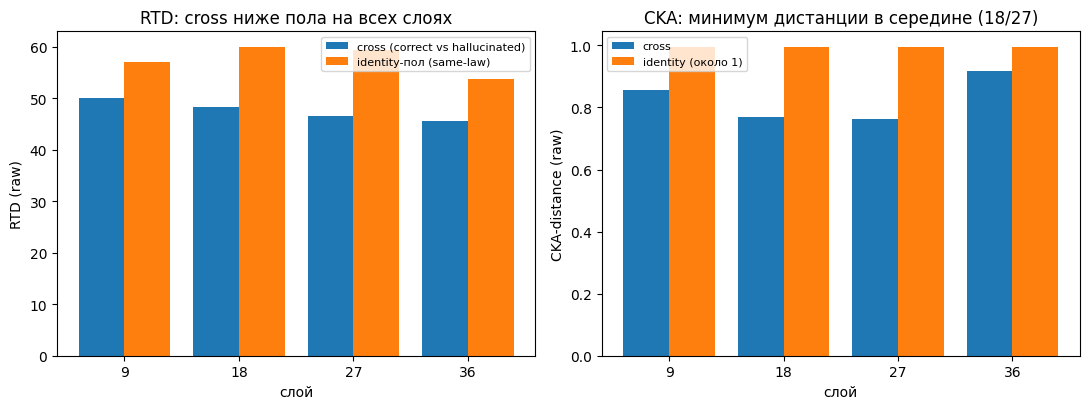

In [ ]:
path = f'{DATA}/raw/wave5/layerwise_summary.json'
lw = json.load(open(path, encoding='utf-8'))
layers = lw['config']['layers']
rows = []
for layer in layers:
    node = lw['by_layer'][str(layer)]
    rows.append({
        'layer': layer,
        'rtd_cross': node['cross']['rtd']['mean'],
        'rtd_floor': node['identity']['rtd']['mean'],
        'cka_cross': node['cross']['cka_distance']['mean'],
        'cka_floor': node['identity']['cka_distance']['mean'],
    })
lwdf = pd.DataFrame(rows).set_index('layer')
print('L5 (dev, n=1000, 5 повторов): cross = correct vs hallucinated; floor = identity (same-law)')
print(lwdf.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
x = np.arange(len(layers))
ax = axes[0]
ax.bar(x - 0.2, lwdf['rtd_cross'], 0.4, label='cross (correct vs hallucinated)')
ax.bar(x + 0.2, lwdf['rtd_floor'], 0.4, label='identity-пол (same-law)')
ax.set_xticks(x, layers)
ax.set_xlabel('слой')
ax.set_ylabel('RTD (raw)')
ax.legend(fontsize=8)
ax.set_title('RTD: cross ниже пола на всех слоях')
ax = axes[1]
ax.bar(x - 0.2, lwdf['cka_cross'], 0.4, label='cross')
ax.bar(x + 0.2, lwdf['cka_floor'], 0.4, label='identity (около 1)')
ax.set_xticks(x, layers)
ax.set_xlabel('слой')
ax.set_ylabel('CKA-distance (raw)')
ax.legend(fontsize=8)
ax.set_title('CKA: минимум дистанции в середине (18/27)')
fig.tight_layout()
plt.show()

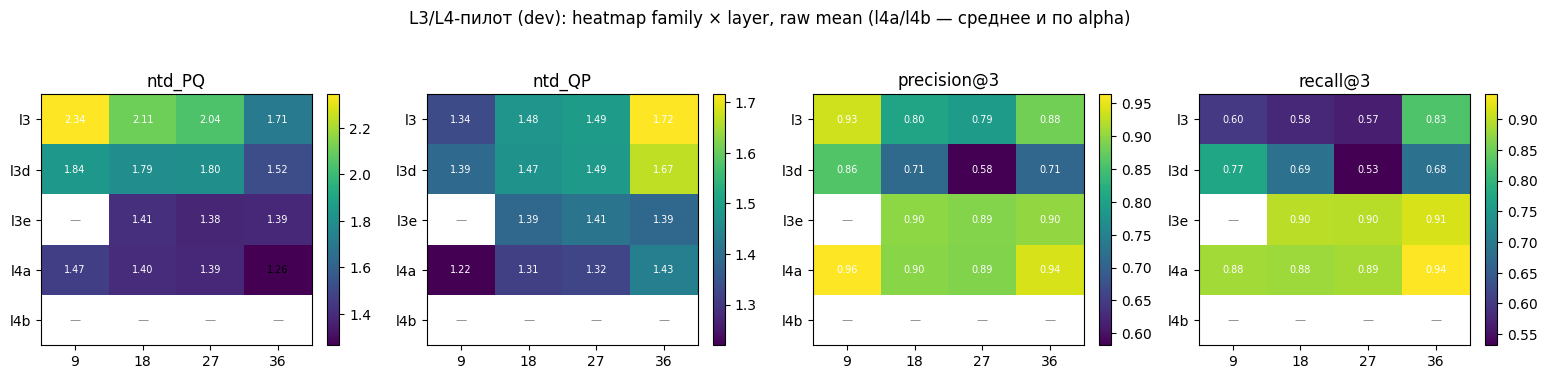

In [ ]:
path = f'{DATA}/raw/llm/results.parquet'
llm = pd.read_parquet(path)
llm = llm[llm['status'] == 'ok']
families = ['l3_direct', 'l3d_length_matched', 'l3e_shuffled_label',
            'l4a_independent', 'l4b_paired']
short = {'l3_direct': 'l3', 'l3d_length_matched': 'l3d', 'l3e_shuffled_label': 'l3e',
         'l4a_independent': 'l4a', 'l4b_paired': 'l4b'}
layers_all = [9, 18, 27, 36]
key_metrics = ['ntd_PQ', 'ntd_QP', 'precision@3', 'recall@3']

fig, axes = plt.subplots(1, 4, figsize=(15.5, 3.6))
for ax, metric in zip(axes, key_metrics):
    grid = (llm.groupby(['experiment_family', 'layer'])[metric].mean()
            .unstack('layer').reindex(index=families, columns=layers_all))
    im = ax.imshow(grid.values, cmap='viridis', aspect='auto')
    vmax = float(np.nanmax(grid.values))
    for a in range(len(families)):
        for b in range(len(layers_all)):
            value = grid.values[a, b]
            if np.isnan(value):
                ax.text(b, a, '—', ha='center', va='center', fontsize=8, color='grey')
            else:
                ax.text(b, a, f'{value:.2f}', ha='center', va='center', fontsize=7,
                        color='white' if value > 0.55 * vmax else 'black')
    ax.set_xticks(range(len(layers_all)), layers_all)
    ax.set_yticks(range(len(families)), [short[f] for f in families])
    ax.set_title(metric)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle('L3/L4-пилот (dev): heatmap family × layer, raw mean (l4a/l4b — среднее и по alpha)', y=1.04)
fig.tight_layout()
plt.show()

**Ответ.**
- **Cross-RTD ниже same-law пола на всех слоях** (cross 50.1 -> 45.6 при поле 57.1 -> 53.8): hallucinated-облако ближе к correct, чем два same-law correct-облака друг к другу — топологическая «концентрация» галлюцинированных ответов; спуск cross к слою 36 — усиление сигнала с глубиной.
- **CKA**: cross 0.76-0.92 против identity-нуля около 0.99 — общая линейная структура скрытых представлений сохранна; **минимум CKA-дистанции в середине сети (слои 18/27)**.
- Heatmap family × layer: l3/l3d отклоняются от l3e-пола на всех слоях (кроме отсутствующей ячейки l3e/9); l4a/l4b усреднены по alpha — дозовые кривые в §8.

Ограничения: слой 18 — primary по пре-регистрации D-010 (выбор сделан до данных); «оптимальный слой» не формулируем — сетка грубая (4 слоя = 25/50/75/100% глубины, mean-pooling; MUST-оговорка G-3/§14-7 wave2-3-5); layerwise RTD на независимых облаках — exploratory random-coupling (trials=2); механика «cross ниже пола» (концентрация против меньшего разброса hallucinated) этими данными не различается — вопрос к баркодам (Next phase).

## §10. Практическая batch-level задача

**Вопрос.** Решена ли практическая batch-level задача обнаружения (L9: ridge/logistic на feature groups)?

**Ответ. Не исполнено — Next phase.** Batch-level задача (L9: бинарное обнаружение батча с галлюцинациями и оценка доли по векторизованным метрикам/feature groups, качество feature groups — 12-я headline-фигура мастер-плана §15) в испытательную дугу Wave 2/3/5 не входила. Всё описанное выше — метрики несходства облаков; детектор на их основе — отдельный шаг с собственными контролями утечки (сплиты по `prompt_id`, обучение только на train). Связанное ограничение мастер-плана §16-1: batch-level обнаружение не является индивидуальным детектором галлюцинаций.

## §11. Надёжность, power и стоимость

**Вопрос.** Какое минимальное n нужно каждой метрике для обнаружения эффекта с power >= 0.8 (alpha = 0.05), и что это стоит по времени?

Power-скан: минимальное n с power >= 0.8 (alpha_sig=0.05; порог — квантиль same-law контроля того же n)
пусто = порог 0.8 не достигнут на сетке n <= 1000
effect        drop0.1  drop0.25  invent0.15  invent0.5
metric                                                
frechet         100.0     100.0       100.0      100.0
js             1000.0     100.0       250.0      250.0
mmd             250.0     100.0       100.0      100.0
mtd_PQ              —     100.0       250.0      500.0
mtd_QP              —         —           —          —
ntd_PQ          500.0     250.0           —          —
ntd_QP              —         —       250.0      250.0
precision@1         —         —           —          —
precision@10        —         —           —          —
precision@3         —         —           —          —
recall@1            —         —           —          —
recall@10           —         —           —          —
recall@3            —         —           —          —
rtd                 —

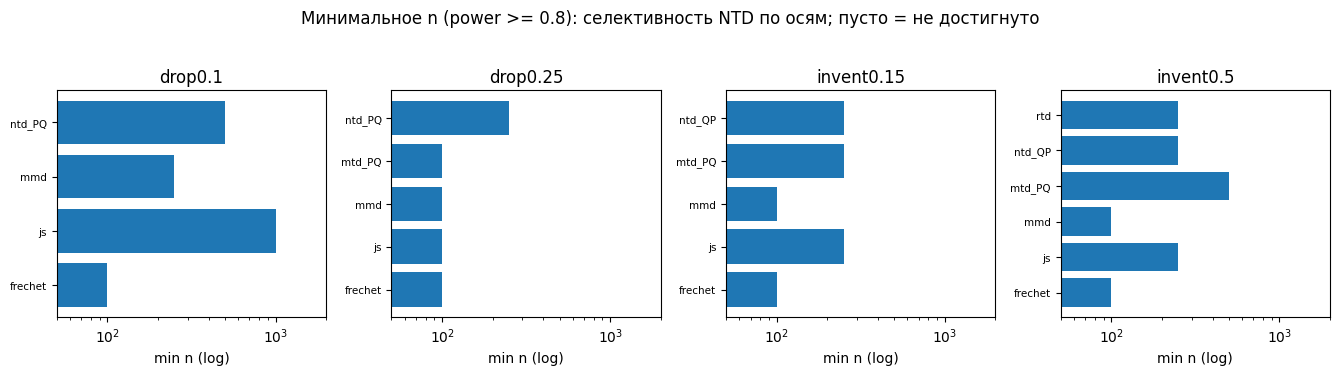

In [ ]:
path = f'{DATA}/tables/power_min_n.csv'
pm = pd.read_csv(path)
pm05 = pm[pm['alpha'] == 0.05]
effects = ['drop0.1', 'drop0.25', 'invent0.15', 'invent0.5']
tab = pm05.pivot(index='metric', columns='effect', values='min_n')[effects]
print('Power-скан: минимальное n с power >= 0.8 (alpha_sig=0.05; порог — квантиль same-law контроля того же n)')
print('пусто = порог 0.8 не достигнут на сетке n <= 1000')
print(tab.to_string(na_rep='—'))

path = f'{DATA}/tables/power_notes.json'
notes = json.load(open(path, encoding='utf-8'))
print(f"\nn_control = {notes['n_control']}, n_effect = {notes['n_effect']}")
for effect, note in notes['effects_discrete'].items():
    print(f'  {effect}: {note}')

path = f'{DATA}/tables/power_summary.csv'
ps = pd.read_csv(path)
sub = ps[(ps['alpha'] == 0.05) & (ps['effect'] == 'drop0.1')]
power_tab = sub.pivot(index='metric', columns='n', values='power')
print('\nПример (drop0.1, alpha=0.05): power по n')
print(power_tab.round(2).to_string())

fig, axes = plt.subplots(1, 4, figsize=(13.5, 3.6))
for ax, effect in zip(axes, effects):
    vals = pm05[pm05['effect'] == effect].set_index('metric')['min_n'].dropna()
    ax.barh(range(len(vals)), vals.values)
    ax.set_yticks(range(len(vals)), vals.index, fontsize=7.5)
    ax.set_title(effect)
    ax.set_xscale('log')
    ax.set_xlim(50, 2000)
    ax.set_xlabel('min n (log)')
fig.suptitle('Минимальное n (power >= 0.8): селективность NTD по осям; пусто = не достигнуто', y=1.03)
fig.tight_layout()
plt.show()

**Ответ.**
- **Селективность NTD воспроизводится в обнаружительной постановке**: ntd_PQ ловит drop (min_n 500/250), ntd_QP — invent (250); каждая метрика слепа к чужой оси. **Fréchet/MMD — самые дешёвые универсальные детекторы** (min_n 100-1000, frechet 100 почти всюду), но не различают тип ошибки (вывод синтетики сохраняется). JS деградирует на малых n (drop0.1: min_n 1000). RTD (random-coupling) достигает порога только на самом крупном invent0.5 (250).
- PR-метрики в одностороннем greater-тесте мощность не показывают (эффект PR — в левом хвосте); их чувствительность измерена S4-синтетикой и C1-контрастами (§§4-5).
- **Стоимость** (фаза 1, compute_all на 1000+1000 точек, executed-артефакт `results/topology_metrics_output.ipynb`): RTD около 17 с — узкое место; MTD около 3 с; improved PR около 1.2 с; статистические около 0.1 с; NTD 1-2 с и сравнима между экспериментами и пространствами. Практический вывод: скрининг — Fréchet/MMD; направленная диагностика — NTD (дёшево и селективно); RTD — только paired/естественные постановки.

Ограничения: минимальное n синтетического power-скана — **ориентир для хорошо разделимых 8-модовых эффектов, не прямая оценка для LLM** (MUST-оговорка H-4); ярлыки drop0.1/invent0.15 — округления к целым модам (1/8 = 12.5%, 2/8 = 25%; H-2); NTD-пол на n=100 систематически завышен (H-5); min_n при alpha=0.05 — консервативная оценка (при 0.1/0.2 порог достигается не позже).

## §12. Итоги и ограничения

**Вопрос.** Что в итоге можно утверждать и какие оговорки обязательны в тексте курсовой?

**Ответ. Executive-выводы** (по отчётам испытательной дуги wave2-3-5 §1):

1. **Направленная селективность метрик подтверждена статистически** — синтетика (S3/S4, 625/625 строк, 0 failed) и все CV-пространства (280/280): recall-семейство (`ntd_PQ`, `recall@k`) ловит mode dropping и слепо к mode invention; precision-семейство (`ntd_QP`, `precision@k`) — зеркально. «Класс = топологическая мода» — подтверждённая рабочая гипотеза.
2. **NTD направленно-селективен и в обнаружительной постановке** (power: min_n 500/250 на своей оси, слепота к чужой) и **кросс-пространственно сравним** (same-law пол 1.22-1.27 в 6 CV-пространствах, 1.20-1.36 в синтетике при n>=500) — уникальное свойство среди топологических метрик.
3. **Геометрия скрытых состояний Qwen2.5-3B различает correct/hallucinated** (HaluEval QA): precision@3 0.758 ± 0.034 на held-out test при same-law пороге 0.957 — единственная подтверждённая по пре-регистрации D-010 primary-метрика; монотонная дозозависимость по всем шести рядам (paired RTD 6.9 -> 47.1, CKA 0.14 -> 0.76); сигнал выживает после length-matched контроля и умирает при shuffled-метках; послойно cross-RTD ниже same-law пола на всех слоях, CKA-минимум в середине сети.
4. **Тип CV-порчи различается топологически при (частично) matched-MMD**: noise бьёт по обеим осям PR, blur асимметричен (recall много меньше precision), brightness/contrast слабы — профиль метрик несводим к величине сдвига.
5. **Отрицательные результаты зафиксированы как результаты**: ntd_QP не детектируется на val при порогах синтетического power (слабый согласованный сдвиг около 1.1σ); recall@3 — только с alpha = 0.5; precision@k слепы к drop, recall@k — к invent; RTD в power — только invent0.5.

**Финальные ограничения мастер-плана §16** (обязательные к явному написанию): batch-level обнаружение — не индивидуальный детектор галлюцинаций; различие hidden-state распределений не доказывает причинную связь с фактической корректностью; возможен style/source-конфаунд датасета; длина и тема ответов должны контролироваться; результаты зависят от LLM, слоя, pooling и PCA; MTD/RTD имеют геометрически зависимый шумовой пол; RTD на независимых облаках — случайная связка (paired методологически естественнее); improved PR зависит от k и размерности; JS может быть нестабилен при малом n×d; значимость на повторных подвыборках одного корпуса не равна независимой внешней репликации; CV-порча — не прямая модель языковой галлюцинации (методическая валидация); отрицательные результаты сохраняются и обсуждаются, а не скрываются.

**Полные MUST-оговорки**: `docs/orchestration/reports/synthetic/REPORT.md` §14 (10 пунктов) и `docs/orchestration/reports/wave2-3-5/REPORT.md` §14 (17 пунктов) — обязательный минимум текста курсовой; сырые данные: `results/raw/{synthetic, cv, power, llm, llm_cache, c3, wave5}`.

=== FINAL NOTEBOOK COMPLETE ===